In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import itertools
import matplotlib.dates as mdates

In [2]:
annotations = pd.read_csv('../../annotations/final_labels_rq2.csv')
df = pd.read_csv('../../all_20_output.csv')

C:\Users\hanna\AppData\Local\Temp\ipykernel_20428\188322614.py:2: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../all_20_output.csv')


In [3]:
df_filtered = df.loc[df['Role'] != 'Presidency']
df_filtered = df_filtered[df_filtered['Interjector'] != df_filtered['Speaker']]
df_filtered['Interjector Party'] = df_filtered['Interjector Party'].replace("GRÜNE", "GRUENE")
df_filtered['Interjector Party'] = df_filtered['Interjector Party'].replace("CDU/CSU]", "CDU/CSU")

df_filtered_speeches = df_filtered.loc[df_filtered['Interjection'] == False]
df_filtered_speeches = df_filtered_speeches.drop(
    columns=[
        'Interjection Text', 'Interjection', 'Interjector',
        'Interjector Gender', 'Interjector Party',
        'Verbal interjection', 'Nonverbal interjection',
        'Interjection type', 'Interjection tokens', 'interjection_token_count'
    ]
)
df_filtered_speeches = df_filtered_speeches.copy()
df_filtered_speeches['Date'] = pd.to_datetime(df_filtered_speeches['Date'], dayfirst=True)
df_filtered_speeches['Month'] = df_filtered_speeches['Date'].dt.to_period('M')
df_filtered_speeches['Week'] = df_filtered_speeches['Date'].dt.to_period('W').apply(lambda r: r.start_time)
df_filtered_speeches['Year'] = df_filtered_speeches['Date'].dt.to_period('Y')

token_df_month_parties = (
        df_filtered_speeches[df_filtered_speeches['Party'].isin(["GRUENE", "SPD", "FDP"])]
        .groupby(["Month", "Party"])['paragraph_token_count']
        .sum()
        .reset_index(name='speech_tokens')
    )

In [4]:
annotations["Interjection Label No Party"] = annotations["Interjection Label"].apply(
    lambda x: ", ".join(
        {
            "_".join(part.strip().split("_")[:-1])
            if part.strip().count("_") >= 2
            else part.strip()
            for part in x.split(",")
        }
    )
)

In [5]:
annotations["Interjection Label List No Party"] = annotations["Interjection Label No Party"].apply(
    lambda x: [s.strip() for s in x.split(",")])

annotations["UndirectedPartyPair"] = annotations.apply(
    lambda row: "-".join(sorted([row["Party"], row["Interjector Party"]])),
    axis=1
)

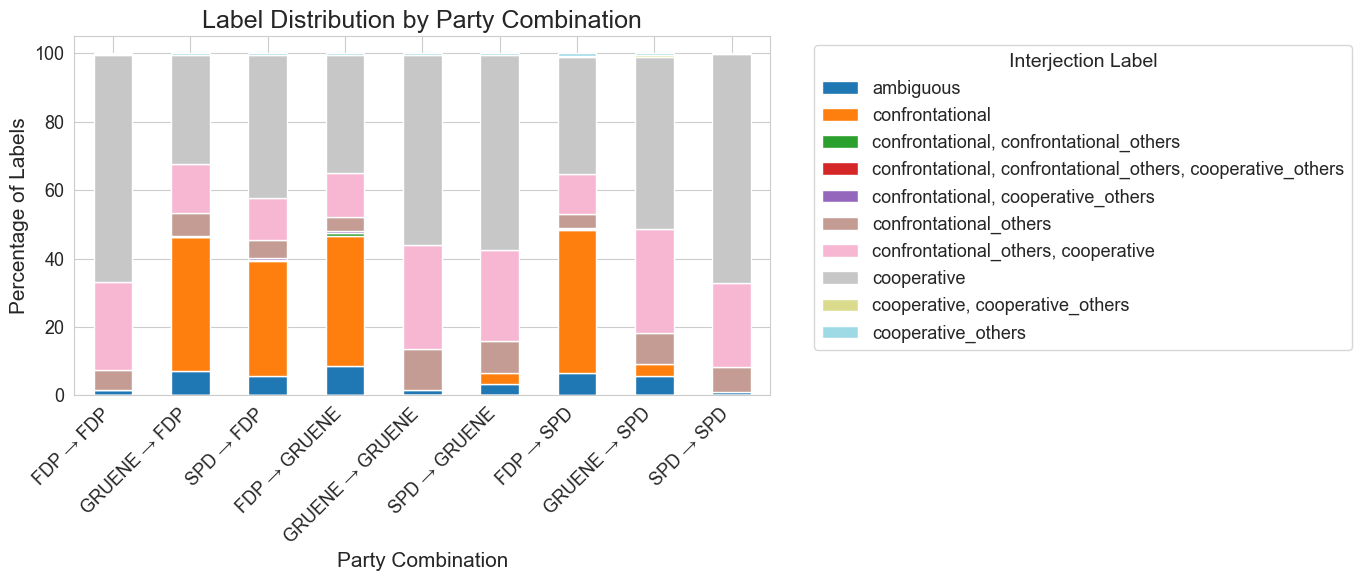

In [150]:
def plot_label_distribution_by_party_combo(df, label_col='Interjection Label No Party',
                                           party_col='Party', interjector_col='Interjector Party',
                                           output_file='party_combo_distribution.png',
                                           title='Label Distribution by Party Combination'):
    """
    Plots the distribution of labels for each Party + Interjector Party combination.
    """
    sns.set_style("whitegrid")

    grouped = df.groupby([party_col, interjector_col])[label_col].value_counts()
    grouped = grouped.rename("Count").reset_index()

    pivot = grouped.pivot_table(
        index=[party_col, interjector_col],
        columns=label_col,
        values='Count',
        fill_value=0
    )

    pivot_percentage = pivot.div(pivot.sum(axis=1), axis=0) * 100

    x_labels = ['{} → {}'.format(ip, p) for p, ip in pivot_percentage.index]

    pivot_percentage.plot(
        kind='bar',
        stacked=True,
        figsize=(14,6),
        colormap='tab20'
    )

    plt.ylabel("Percentage of Labels")
    plt.xlabel("Party Combination")
    plt.title(title)
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45, ha='right')
    plt.legend(title="Interjection Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()

plot_label_distribution_by_party_combo(annotations)


In [151]:
def compute_confrontational_share(df,
                                  list_col='Interjection Label List No Party',
                                  party_col='Party',
                                  interjector_col='Interjector Party'):
    """
    Returns a dataframe with the share of confrontational interjections
    per party combination (Interjector → Speaker), including counts.
    """

    df = df.copy()

    # Binary flag: confrontational?
    df['confrontational'] = df[list_col].apply(lambda labels: int("confrontational" in labels))

    # Aggregate: mean confrontational per combination
    agg = (df.groupby([interjector_col, party_col])
             .agg(confrontational_count=('confrontational', 'sum'),  # number of confrontational interjections
                  n=('confrontational', 'size'))                    # total interjections
             .reset_index())

    # Compute share of 'confrontational' overall (i.e., is 'confrontational' one of the assigned labels?)
    agg['confrontational_share_pct'] = (agg['confrontational_count'] / agg['n']) * 100

    agg['combo'] = agg[interjector_col].str.replace("GRUENE", "Greens") + " → " + agg[party_col].str.replace("GRUENE", "Greens")

    return agg[['combo', 'n', 'confrontational_count', 'confrontational_share_pct']]

In [152]:
split_date = pd.Timestamp("2024-11-07")
annotations['Date'] = pd.to_datetime(annotations['Date'], dayfirst=True)
annotations_inter = annotations[annotations["Party"] != annotations["Interjector Party"]]

In [153]:
# Before November 7
annotations_inter_before = annotations_inter[annotations_inter['Date'] < split_date]
# After November 7 (including 7th)
annotations_inter_after = annotations_inter[annotations_inter['Date'] >= split_date]

In [154]:
overall_table = compute_confrontational_share(annotations_inter)
before_table = compute_confrontational_share(annotations_inter_before)
after_table  = compute_confrontational_share(annotations_inter_after)

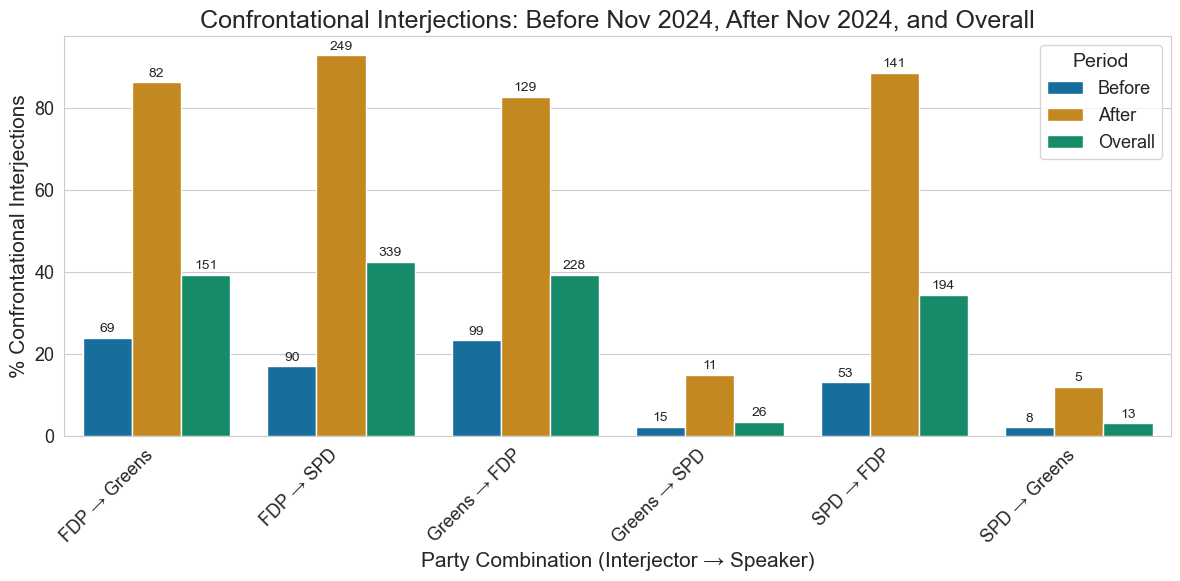

In [158]:
# Add column to identify each table
before_table['Period'] = 'Before'
after_table['Period']  = 'After'
overall_table['Period'] = 'Overall'

# Combine
combined = pd.concat([before_table, after_table, overall_table], ignore_index=True)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=combined,
    x='combo',
    y='confrontational_share_pct',
    hue='Period',
    palette='colorblind'
)

# Add counts on top of bars
for container, period in zip(ax.containers, ['Before','After','Overall']):
    # container holds all bars for this hue
    counts = combined[combined['Period'] == period]['confrontational_count'].values
    ax.bar_label(container, labels=counts, label_type='edge', fontsize=10, padding=2)

plt.ylabel("% Confrontational Interjections")
plt.xlabel("Party Combination (Interjector → Speaker)")
plt.xticks(rotation=45, ha='right')
plt.title("Confrontational Interjections: Before Nov 2024, After Nov 2024, and Overall")
plt.legend(title="Period", loc="upper right")
plt.tight_layout()
plt.show()

In [6]:
annotations['Date'] = pd.to_datetime(annotations['Date'], dayfirst=True)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

annotations['Month'] = annotations['Date'].dt.to_period('M')
df['Month'] = df['Date'].dt.to_period('M')

annotations['Week'] = annotations['Date'].dt.to_period('W').apply(lambda r: r.start_time)
df['Week'] = df['Date'].dt.to_period('W').apply(lambda r: r.start_time)

annotations['Year'] = annotations['Date'].dt.to_period('Y')
df['Year'] = df['Date'].dt.to_period('Y')

In [7]:
annotations["Interjection Label No Party"] = annotations["Interjection Label"].apply(
    lambda x: ", ".join(
        {
            "_".join(part.strip().split("_")[:-1])
            if part.strip().count("_") >= 2
            else part.strip()
            for part in x.split(",")
        }
    )
)

annotations["Interjection Label List No Party"] = annotations["Interjection Label No Party"].apply(
    lambda x: [s.strip() for s in x.split(",")])

In [8]:
interjection_counts_month_party = (
    annotations.groupby(["Month", "Party", "Interjector Party", "Interjection Label No Party"])
    .size()
    .reset_index(name="Interjection Count")
)

In [10]:
merged_month = interjection_counts_month_party.merge(
    token_df_month_parties,
    how="left",
    on=["Party", "Month"]  # normalize by tokens spoken by the target party in that month
)

In [12]:
merged_month["Normalized"] = (merged_month["Interjection Count"] / merged_month["speech_tokens"]) * 10000

In [17]:
def net_mood_score(labels):
    score = 0
    if 'cooperative' in labels:
        score += 1
    if 'confrontational' in labels:
        score -= 1
    return score

In [18]:
annotations['InterjectionScore'] = annotations['Interjection Label List No Party'].apply(net_mood_score)
annotations['PartyPair'] = annotations['Interjector Party'] + "–>" + annotations['Party']

In [19]:
annotations_inter = annotations[annotations["Party"] != annotations["Interjector Party"]]

In [95]:
# 1. Aggregate interjections per Month + PartyPair (spd->fdp: -1, fdp->spd:-8)
df_monthly_pair = annotations_inter.groupby(['Month', 'PartyPair', 'Party']).agg({
    'InterjectionScore': 'sum'
}).reset_index()

In [96]:
# 2. Merge in the speaker token counts (to later normalize by speaker party)
df_monthly_pair = df_monthly_pair.merge(
    token_df_month_parties,
    on=['Month', 'Party'],
    how='left'
)

# calculate interjection rate per 10000 tokens (normalized by tokens spoken by speaker party)
df_monthly_pair['interjection_rate'] = df_monthly_pair['InterjectionScore'] / df_monthly_pair['speech_tokens'] * 10000

In [97]:
df_monthly_pair

,Month,PartyPair,Party,InterjectionScore,speech_tokens,interjection_rate
0,2021-11,FDP–>GRUENE,GRUENE,1,11447,0.873591
1,2021-11,FDP–>SPD,SPD,1,20611,0.485178
2,2021-11,GRUENE–>FDP,FDP,1,9654,1.035840
3,2021-11,GRUENE–>SPD,SPD,0,20611,0.000000
4,2021-11,SPD–>FDP,FDP,2,9654,2.071680
...,...,...,...,...,...,...
221,2025-03,FDP–>SPD,SPD,-9,12537,-7.178751
222,2025-03,GRUENE–>FDP,FDP,-2,7810,-2.560819
223,2025-03,GRUENE–>SPD,SPD,-2,12537,-1.595278
224,2025-03,SPD–>FDP,FDP,-3,7810,-3.841229


In [93]:
# Aggregate interjections (raw score) per Month + PartyPair + Party + Interjector Party
df_monthly_pair = annotations_inter.groupby(
    ['Month', 'PartyPair', 'Party', 'Interjector Party']
).agg({'InterjectionScore': 'sum'}).reset_index()

# Get all unique months and party pairs (to avoid empty rows that would fall away instead of being 0)
months = df_monthly_pair['Month'].unique()
party_pairs = df_monthly_pair['PartyPair'].unique()

# Create all Month × PartyPair combinations
all_combinations = pd.DataFrame(list(itertools.product(months, party_pairs)),
                                columns=['Month', 'PartyPair'])

# Merge Party column from the original df
party_mapping = df_monthly_pair[['PartyPair', 'Party']].drop_duplicates()
all_combinations = all_combinations.merge(party_mapping, on='PartyPair', how='left')

df_full = all_combinations.merge(df_monthly_pair, on=['Month', 'PartyPair', 'Party'], how='left')

# Fill missing InterjectionScore with 0 (no interjections recorded for pair)
df_full['InterjectionScore'] = df_full['InterjectionScore'].fillna(0)

# obtain speech tokens by speaker party
df_full = df_full.merge(token_df_month_parties, on=['Month', 'Party'], how='left')

# Fill missing speech_tokens with 0
df_full['speech_tokens'] = df_full['speech_tokens'].fillna(0)

# normalize interjection reate
df_full['interjection_rate'] = df_full['InterjectionScore'] / df_full['speech_tokens'] * 10000
df_full['interjection_rate'] = df_full['interjection_rate'].fillna(0)
df_full = df_full.drop(columns=['Interjector Party'])

In [98]:
df_full.to_csv("R/data/interjectionscorebymonthpartypair.csv", index=False)

In [179]:
annotations_inter["UndirectedPartyPair"] = annotations_inter.apply(
    lambda row: "-".join(sorted([row["Party"], row["Interjector Party"]])),
    axis=1
)

C:\Users\hanna\AppData\Local\Temp\ipykernel_12912\3724009281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotations_inter["UndirectedPartyPair"] = annotations_inter.apply(


In [180]:
annotations_inter

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,flagged_phaseIII,entropy_phaseIII,Interjection Label No Party,Interjection Label List No Party,UndirectedPartyPair,Month,Week,Year,InterjectionScore,PartyPair
0,20_0002.xml,20,2021-11-11,3,7,Franziska Brantner,NaN,weiblich,GRUENE,SPD,...,NaN,NaN,cooperative,[cooperative],GRUENE-SPD,2021-11,2021-11-08,2021,1,SPD–>GRUENE
1,20_0002.xml,20,2021-11-11,4,4,Till Mansmann,NaN,männlich,FDP,SPD,...,NaN,NaN,cooperative,[cooperative],FDP-SPD,2021-11,2021-11-08,2021,1,SPD–>FDP
2,20_0002.xml,20,2021-11-11,4,4,Till Mansmann,NaN,männlich,FDP,SPD,...,NaN,NaN,cooperative,[cooperative],FDP-SPD,2021-11,2021-11-08,2021,1,SPD–>FDP
4,20_0002.xml,20,2021-11-11,9,6,Reinhard Houben,NaN,männlich,FDP,GRUENE,...,NaN,NaN,ambiguous,[ambiguous],FDP-GRUENE,2021-11,2021-11-08,2021,0,GRUENE–>FDP
5,20_0003.xml,20,2021-11-18,3,5,Ekin Deligöz,NaN,weiblich,GRUENE,FDP,...,NaN,NaN,cooperative,[cooperative],FDP-GRUENE,2021-11,2021-11-15,2021,1,FDP–>GRUENE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,20_0213.xml,20,2025-03-13,5,16,Johannes Vogel,NaN,männlich,FDP,GRUENE,...,True,0.827598,confrontational,[confrontational],FDP-GRUENE,2025-03,2025-03-10,2025,-1,GRUENE–>FDP
5779,20_0213.xml,20,2025-03-13,4,17,Christian Dürr,NaN,männlich,FDP,GRUENE,...,True,0.499374,"confrontational, confrontational_others, coope...","[confrontational, confrontational_others, coop...",FDP-GRUENE,2025-03,2025-03-10,2025,-1,GRUENE–>FDP
5780,20_0213.xml,20,2025-03-13,15,4,Achim Post,NaN,männlich,SPD,FDP,...,True,0.354835,confrontational,[confrontational],FDP-SPD,2025-03,2025-03-10,2025,-1,FDP–>SPD
5781,20_0214.xml,20,2025-03-18,10,1,Franziska Brantner,NaN,weiblich,GRUENE,FDP,...,True,0.391014,confrontational,[confrontational],FDP-GRUENE,2025-03,2025-03-17,2025,-1,FDP–>GRUENE


In [116]:
# do same as before but for undirected pairs

df_monthly_undirected_pair = annotations_inter.groupby(
    ['Month', 'Party', 'UndirectedPartyPair']
).agg({'InterjectionScore': 'sum'}).reset_index()

months = df_monthly_undirected_pair['Month'].unique()
undirected_pairs = df_monthly_undirected_pair['UndirectedPartyPair'].unique()
party_mapping = df_monthly_undirected_pair.groupby('UndirectedPartyPair')['Party'].unique().to_dict()

all_rows = []
for month in months:
    for pair in undirected_pairs:
        for party in party_mapping[pair]:
            all_rows.append({'Month': month, 'UndirectedPartyPair': pair, 'Party': party})

all_combinations = pd.DataFrame(all_rows)

df_full = all_combinations.merge(
    df_monthly_undirected_pair,
    on=['Month', 'UndirectedPartyPair', 'Party'],
    how='left'
)
df_full['InterjectionScore'] = df_full['InterjectionScore'].fillna(0)

df_full = df_full.merge(token_df_month_parties, on=['Month', 'Party'], how='left')

df_undirected = df_full.groupby(['Month', 'UndirectedPartyPair']).agg({
    'InterjectionScore': 'sum',
    'speech_tokens': 'sum'
}).reset_index()

df_undirected['interjection_rate'] = df_undirected['InterjectionScore'] / df_undirected['speech_tokens'] * 10000

In [118]:
df_undirected.to_csv("R/data/interjectionscorebymonthundirected.csv", index=False)

In [ ]:
# obtain data by (directed) party pair, overall, independent of month

In [187]:
token_df_parties = (
        df_filtered_speeches[df_filtered_speeches['Party'].isin(["GRUENE", "SPD", "FDP"])]
        .groupby(["Party"])['paragraph_token_count']
        .sum()
        .reset_index(name='speech_tokens')
    )

df_pair = annotations_inter.groupby(['PartyPair', 'Party']).agg({
    'InterjectionScore': 'sum'
}).reset_index()

df_pair = df_pair.merge(
    token_df_parties,
    on=['Party'],
    how='left'
)

df_pair['interjection_rate'] = df_pair['InterjectionScore'] / df_pair['speech_tokens'] * 10000

In [188]:
df_pair

,PartyPair,Party,InterjectionScore,speech_tokens,interjection_rate
0,FDP–>GRUENE,GRUENE,30,2048361,0.146459
1,FDP–>SPD,SPD,28,3362722,0.083266
2,GRUENE–>FDP,FDP,40,1635645,0.244552
3,GRUENE–>SPD,SPD,575,3362722,1.709924
4,SPD–>FDP,FDP,111,1635645,0.678631
5,SPD–>GRUENE,GRUENE,337,2048361,1.645218


In [189]:
df_pair.to_csv("R/data/interjectionscorebypartypair.csv", index=False)